In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Example Notebook
This notebook demonstrates how to prepare data, give that data to the sparse bias model, and analyze the results. 

### The sparse bias model
Explain the sparse bias model

#### Linking Stan
The model is built around the stan code, which is a PPL that leverages Hamiltonian and Markov Chain Monte Carlo to draw samples from complex distributions.
The first step is to link the stan command line tool `cmdstan` to your python environment.
More instructions on this can be found at https://mc-stan.org/cmdstanpy/.

In [5]:
#%%
from cmdstanpy import cmdstan_path, set_cmdstan_path

set_cmdstan_path("/Users/nwalton/Software/cmdstan-2.36.0/")
print(cmdstan_path())

/Users/nwalton/Software/cmdstan-2.36.0


### Fake data

This example notebook will demonsrate the use of the bias identification model using fake/simulated data. 
This data curation step will vary from problem to problem. 
We've provided some utilities for the user, as well as some problem specific tools related to the AIACHNE and PARADIGM projects (add references).
However, the goal is to make the sparse bias model probelem agnostic, requiring some user effort to prepare there data in the proper format.

In [69]:
from utils.functions import maxwellian 

def make_measurement(xmin, xmax, N_obs, relative_unc):
    x_obs = np.logspace(np.log10(xmin),np.log10(xmax), N_obs)
    y_obs_mean = maxwellian(1.5, x_obs)
    y_obs_unc = y_obs_mean*relative_unc
    y_obs = np.random.default_rng(seed).multivariate_normal(mean=y_obs_mean, cov=np.diag(y_obs_unc**2))
    return x_obs, y_obs, y_obs_unc

seed = 1
N_exp = [20,7,15]
x_range = np.log10((1e-5,12))
x_eval = np.logspace(*x_range, 12)

x_obs1, y_obs1, y_obs1_unc = make_measurement(2e-5, 11, N_exp[0], 0.2) 
x_obs2, y_obs2, y_obs2_unc = make_measurement(1e0, 11, N_exp[1], 0.5) 
x_obs3, y_obs3, y_obs3_unc = make_measurement(1e-2, 11, N_exp[2], 0.2) 

## optional bias on exp 2
y_obs2 += x_obs2*-1e-3 + 0.01*x_obs2
y_obs2[y_obs2<0 ]=0
y_obs2_unc = y_obs2*0.5

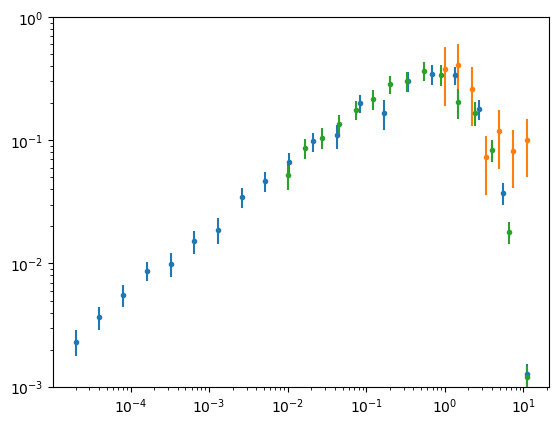

In [ ]:
plt.figure()
plt.errorbar(x_obs1, y_obs1, yerr=y_obs1_unc, fmt='.')
plt.errorbar(x_obs2, y_obs2, yerr=y_obs2_unc, fmt='.')
plt.errorbar(x_obs3, y_obs3, yerr=y_obs3_unc, fmt='.')
# plt.errorbar(all_df["energy"], np.array(stan_data['y']), yerr=np.array(stan_data['s'])*np.array(stan_data['y']), fmt = '.')

plt.ylim(1e-3, 1)
plt.xscale('log')
plt.yscale('log')
plt.show()

The basic input data structure that the user should curate is a dictionary with the following fields:

- X             : definition
- expt_value    : definition
- rel_unc       : definition
- expt_label    : definition
- bias_label    : definition
- scale_flag    : definition
- corr          : definition

This dictionary can be constructed for the entire data set and given directly to the sparse_bias model classes. 

Alternatively, this dictionary can be constructed for each individual data set, and the general utility function compile_data_dicts can be used to combine them. This function performs does two primary things.
First, it broadcasts scalar values (such as bias_label or scale_flag) to match the size of the other fields.
Second, it concatenates the fields of each individual dataset into a single dictionary that can be give to the sparse bias model classes.
As a part of the second step, it will also properly handle the correlation matrices, though if you have correlations between data set dicts these will need to be added afterwards.

In [71]:
data1 = {'X'        : x_obs1,
       'expt_value' : y_obs1,
       'rel_unc'    : y_obs1_unc/y_obs1,
       'expt_label' : 'exp1',
       'bias_label' : 'a',
       'scale_flag' : 0,
       'corr'       : np.eye(len(x_obs1)) }

data2 = {'X'        : x_obs2,
       'expt_value' : y_obs2,
       'rel_unc'    : y_obs2_unc/y_obs2,
       'expt_label' : 'exp2',
       'bias_label' : 'b',
       'scale_flag' : 1,
       'corr'       : np.eye(len(x_obs2)) }

data3 = {'X'        : x_obs3,
       'expt_value' : y_obs3,
       'rel_unc'    : y_obs3_unc/y_obs3,
       'expt_label' : 'exp3',
       'bias_label' : ['a', 'b'],
       'scale_flag' : 0,
       'corr'       : np.eye(len(x_obs3)) }


data_dict = compile_data_dicts([data1, data2, data3])

In [ ]:
# inspect data_dict

# Constructing the model 

In [74]:
from sparse_bias import BiasModel, BasisModel 
from processing  import convert_to_stan_data

############
#
# Build relevant Basis functions
#
basis_obj = BasisModel(data_dict,
                       mean_basis_type = "interpolation",
                       bias_basis_type = "gaussian")

minE = np.log10(0.0001)
maxE = np.log10(50)

# Gaussian bases for the mean
centers  = np.linspace(minE, maxE, 30)
width    = 0.2
basis_obj.generate_mean_bases(X_grid=x_eval,centers=centers, widths=width)

# Gaussian bases for the bias
centers  = [
    np.linspace(minE, maxE, 10), 
    np.linspace(minE, maxE, 5),
    np.linspace(minE, maxE, 1)
]
widths   = [0.1, 0.5, 1.0]
basis_obj.generate_bias_bases(centers=centers, widths=widths)


## Convert to stan data, select hyperparameters, and run

In [ ]:

############
#
# Convert to a dict in the format for stan
#
stan_data    = convert_to_stan_data(data_dict, basis_obj, tau_scale=1.e-5)
# with open("/Users/nwalton/Software/sparse_bias/stan_files/inp.json", "w") as f:
#     json.dump(stan_data, f)#json.dump(stan_data, "/Users/nwalton/Software/sparse_bias/stan_files/inp.json")
# print(stan_data)

############
#
# Build Sparse Bias Model
#
sbmod = BiasModel(stan_data, basis_obj, model_name = "interpolation_horseshoe")

# fit
sbmod.fit(n_warmup=2000, n_sample=2500, show_console=False)


# Analyze Output

In [ ]:
## add analysis functions

gamma = [nsamples, n_bases, nlevels]

B = [n_obs, n_bases]

for some level, the bias term is $B \times \gamma$ 

where $\gamma^T$ = gamma[:,:,$i_{\mathrm{level}}$] 

and $\gamma$ = [n_bases, nsamples]